In [23]:
import BiSSGL as BiSSGL
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

In [ ]:
# This is new simulation setting for the feature selection:
I = 80
J = 160
d = d1 = d2 = 10
K = K1 = K2 = 3

U = np.random.normal(0, np.sqrt(0.01), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.01), size=(J, d2))
V_true = V[:, :K2]
A_true = np.eye(K1)
B_true = np.eye(K2)


def plot_matrix(mat):
    import matplotlib.pyplot as plt

    plt.imshow(mat, aspect="auto", cmap="viridis")
    plt.colorbar()
    plt.show()


Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.5).astype(int)

sparsity = 0.1
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int(sparsity * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

In [ ]:
# U.shape, V.shape, A_true.shape
A = np.zeros((d1, K))
A[range(K), range(K)] = 1

B = np.zeros((d2, K))
B[range(K), range(K)] = 1

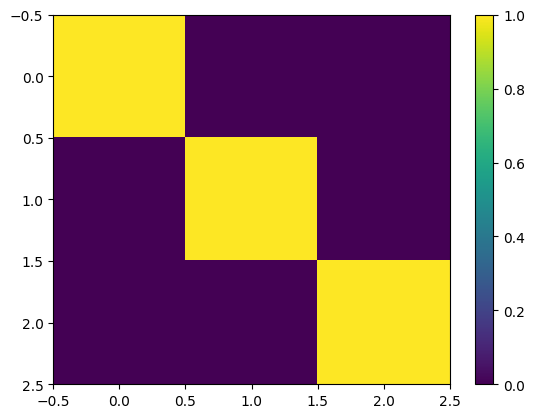

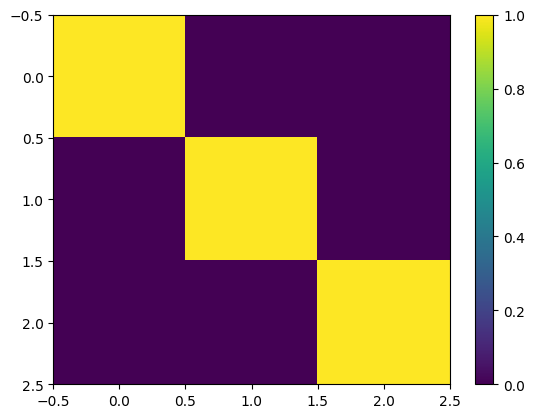

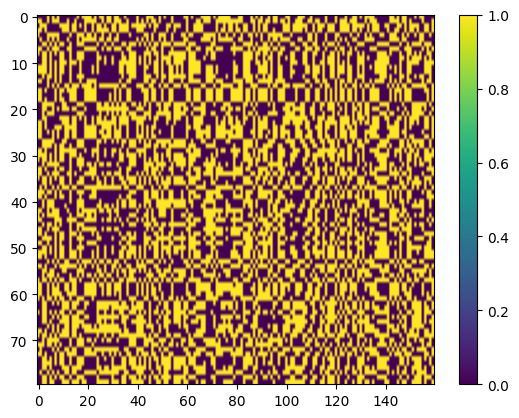

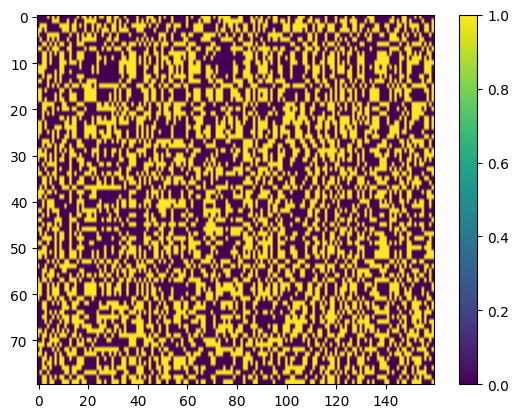

In [35]:
plot_matrix(A_true)
plot_matrix(B_true)
plot_matrix(Y_true)
plot_matrix(Y)

In [109]:
est_mu, est_A, est_B = BiSSGL.optimization(
    Y,
    U=U,
    V=V,
    xi=1,
    eta=1e-3,
    tilde_lambda0=2,
    tilde_lambda1=1,
    tilde_alpha=1,
    tilde_beta=1,
    lambda0=2,
    lambda1=1,
    alpha=1,
    beta=1,
    K=3,
    max_iter=5000,
    tol=1e-5,
    # A = A,
    # B = B
)

Finished with iterations of 1205


In [110]:
print(est_mu)

[-6.77900564e+02 -2.94841292e+02  6.06386000e+01 -1.75251971e+02
 -5.28875923e+02 -4.71571498e+02 -2.65488839e+02 -2.65301662e+02
 -2.36239437e+02 -2.06713419e+02 -2.97022507e+01 -2.35460753e+02
 -2.64879074e+02 -5.01410918e+02 -2.94359053e+02 -8.82446112e+01
 -2.94150152e+02 -3.53172620e+02 -2.94136919e+02 -1.76647161e+02
 -2.05604955e+02 -3.82897565e+02 -1.36889505e-01  8.81065614e+01
 -1.76717070e+02 -1.76394677e+02 -1.76752853e+02 -1.18007800e+02
 -1.76861472e+02 -2.05764878e+02 -5.91663553e+01 -3.23722863e+02
 -5.58676601e+02 -3.52953119e+02 -2.06041707e+02 -2.06620334e+02
 -2.64978338e+02 -2.64748476e+02 -3.52266634e+02 -5.00701959e+02
 -3.23148694e+02 -2.06252254e+02 -5.60537761e+02 -5.90885598e+02
 -5.89624856e+02 -4.41655372e+02 -4.71925874e+02 -3.24143586e+02
 -1.77029995e+02 -3.21483783e+02 -3.24510145e+02  8.81663656e+01
 -2.93219580e+02 -4.12595886e+02 -2.05659348e+02 -3.53442100e+02
 -3.53426953e+02 -1.47554380e+02 -1.47182304e+02 -8.82404565e+01
 -2.06154627e+02 -3.82729

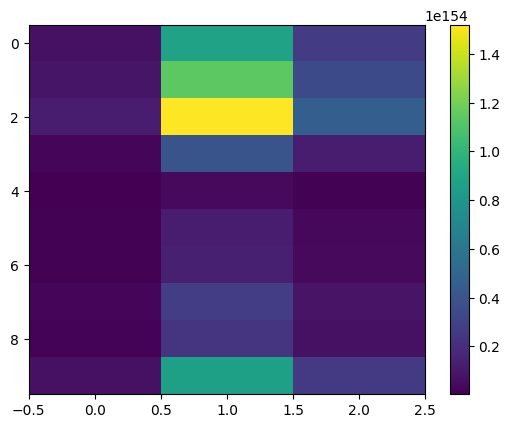

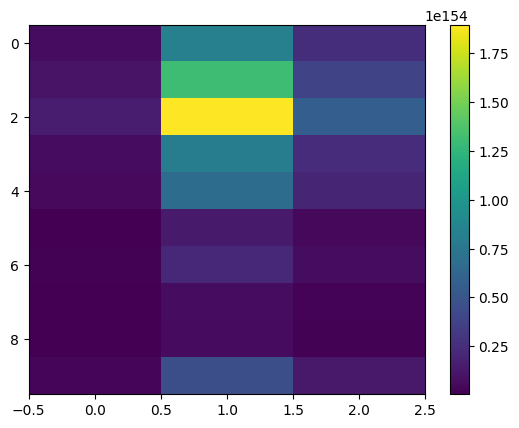

In [111]:
plot_matrix(np.abs(est_A))
plot_matrix(np.abs(est_B))

In [51]:
np.abs(est_A)

array([[8.98891893e+00, 3.76272039e+00, 8.78464901e-01],
       [1.18803289e+01, 6.16494991e+00, 2.56625551e+00],
       [1.76833847e+01, 7.53288177e+00, 6.76501840e+00],
       [2.95828190e+00, 5.30487351e-01, 1.01284138e+00],
       [2.07546962e+00, 2.46450888e-02, 6.81619454e-03],
       [1.62885517e-01, 1.79088608e-02, 2.13720809e-01],
       [9.88175248e-01, 1.02330198e+00, 4.14384444e-01],
       [1.86873313e+00, 1.62107059e+00, 2.56014735e-01],
       [7.74125921e-01, 9.06983594e-01, 1.68303387e-02],
       [5.86783789e+00, 4.67882459e+00, 1.84511579e+00]])